In [147]:
import numpy as np
from tqdm import tqdm
import plotly.graph_objects as go
import math


from energies.bend import Bend
from energies.bend_twist import BendTwist
from energies.gravity import Gravity
from energies.random import RandomForce
from energies.twist import Twist
from math_util.rotation import RotationUtil, Quaternion
from math_util.vectors import Vector
from rod.RodHelixConverter import RodHelixConverter
from rod.helix import Helix
from rod.helix_util import HelixUtil
from rod.preprocess import Preprocess
from rod.rod_generator import RodGenerator
from rod.rod_util import RodUtil
from solver.sim import Sim
from visualization.visualizer import Visualizer
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

np.random.seed(42)

In [ ]:
def strands_to_one_objs(strands: np.ndarray, frame_idx: int, output_file: str = None, y_up: bool = True):
    output_file = f"output/obj/obj_{frame_idx}.obj" if output_file is None else output_file
    Visualizer.clear_output_file(output_file)
    vertex_offset = 1
    for strand in strands:
        pos = strand[:, :3]
        vertex_offset = Visualizer.to_simple_obj(pos=pos, output_file=output_file, init_offset=vertex_offset, y_up=y_up)
    return

def add_one_twist(pos, theta, twist_idx=100, twist_angle_rad=np.pi/2):
    '''
    Apply twist by 90 degrees at index 100
    '''
    helix = RodHelixConverter.rod_to_helix(pos=pos, theta=theta)

    twist_index = twist_idx
    twist_angle_deg = twist_angle_rad * 180 / np.pi
    arc_step = 0.00391252

    # Compute twist rate (tau) per unit arc length
    tau = twist_angle_deg / arc_step  # ~133.93

    # Apply twist at twist_index
    helix.q[3 * twist_index] = tau

    return RodHelixConverter.helix_to_rod(helix=helix)


def add_twist_cum(pos, theta, twist_indices=None, twist_values=None, twist_rate=0.8,
                  twists_per_curl=5, angular_curl_freq=2*np.pi, indices_per_curl=20):
    """
    Add cumulative twist to a rod by injecting twist at selected indices.

    Parameters:
    - pos: (N, 3) array of vertex positions.
    - theta: twist angles (N-1,) — passed through RodHelixConverter.
    - twist_indices: array of indices to apply cumulative twist (optional).
    - twist_values: array of twist angles in radians (optional, same length as twist_indices).
    - twist_rate: fraction of vertices to twist (used if twist_indices is None).
    - twists_per_curl: desired number of twists per curl (used only for computing default twist_rate).
    - angular_curl_freq: angular frequency of the helix (radians per index).
    - indices_per_curl: number of indices per curl (used only for computing default twist_rate).

    Returns:
    - pos_out, theta_out: positions and twists after applying cumulative twist.
    """
    helix = RodHelixConverter.rod_to_helix(pos=pos, theta=theta)
    num_vertices = len(pos)
    num_twist_indices = len(helix.q) // 3

    # Determine how many total twist applications to apply
    if twist_indices is None:
        twist_rate = twists_per_curl / indices_per_curl if twist_rate is None else twist_rate
        total_twists = int(twist_rate * num_vertices)
        twist_indices = np.random.choice(np.arange(num_twist_indices), size=total_twists, replace=False)
    if twist_values is None:
        twist_values = np.random.uniform(-0.05, 0.05, size=len(twist_indices))

    twist_indices = np.array(twist_indices)
    twist_values = np.array(twist_values)
    twist_values = np.degrees(twist_values)
    sorted_order = np.argsort(twist_indices)
    twist_indices = twist_indices[sorted_order]
    twist_values = twist_values[sorted_order]

    # Apply  twist: each twist affects this index and all after
    for i, idx in enumerate(twist_indices):
        delta_twist = twist_values[i] # convert to degrees
        helix.q[3 * idx] += delta_twist  # apply to this edge

    return RodHelixConverter.helix_to_rod(helix=helix)

def in_to_meters(x):
    inches_to_meters = 0.0254
    return x * inches_to_meters

def add_many_rotation_inextensible(pos, theta, twist_indices=None, twist_values=None, twist_rate=0.8, n_iters=50):
    '''
    Apply twist to a rod and project to maintain segment inextensibility.
    Apply twist at designated twist indices by corresponding twist value. Both twist_indices and twist_values must be arrays of the same length.

    Parameters:
    - pos: (N, 3) array of vertex positions.
    - theta: passed through unchanged.
    - twist_indices: array of indices at which to apply twist. If None, randomly chosen.
    - twist_values: array of twist angles (in radians) to apply at the corresponding twist_indices.
    - twist_rate: fraction of segments to twist, if twist_indices not provided.
    - n_iters: number of projection iterations for enforcing inextensibility.

    Returns:
    - pos_rotated: (N, 3) rotated and projected positions.
    - theta: unchanged.
    '''
    pos_rotated = pos.copy()
    num_vertices = len(pos)

    # Rest lengths of each segment
    rest_lengths = np.linalg.norm(pos[1:] - pos[:-1], axis=1)

    max_twist_points = num_vertices - 1
    total_twists = int(twist_rate * max_twist_points)

    # Generate twist indices/values if not provided
    if twist_indices is None:
        twist_indices = np.random.choice(np.arange(max_twist_points), size=total_twists, replace=False)
    if twist_values is None:
        twist_values = np.random.uniform(-0.05, 0.05, size=len(twist_indices))

    for i, twist_index in enumerate(twist_indices):
        if twist_index >= num_vertices - 1:
            continue

        twist_angle = twist_values[i]
        axis = pos[twist_index + 1] - pos[twist_index]
        axis_norm = np.linalg.norm(axis)
        if axis_norm < 1e-8:
            continue
        axis = axis / axis_norm

        # Rodrigues' rotation formula
        K = np.array([
            [0, -axis[2], axis[1]],
            [axis[2], 0, -axis[0]],
            [-axis[1], axis[0], 0]
        ])
        I = np.eye(3)
        R = I + np.sin(twist_angle) * K + (1 - np.cos(twist_angle)) * (K @ K)

        origin = pos[twist_index]
        for j in range(twist_index + 1, num_vertices):
            vec = pos_rotated[j] - origin
            pos_rotated[j] = origin + R @ vec

    # Project to enforce inextensibility
    for _ in range(n_iters):
        for i in range(num_vertices - 1):
            p1, p2 = pos_rotated[i], pos_rotated[i + 1]
            edge = p2 - p1
            current_len = np.linalg.norm(edge)
            if current_len < 1e-8:
                continue
            rest_len = rest_lengths[i]
            correction = 0.5 * (1 - rest_len / current_len) * edge
            pos_rotated[i] += correction
            pos_rotated[i + 1] -= correction

    return pos_rotated, theta


def project_inextensibility(pos, rest_lengths, max_iters=10, tol=1e-6):
    for _ in range(max_iters):
        diffs = pos[1:] - pos[:-1]
        seg_lengths = np.linalg.norm(diffs, axis=1)
        errors = seg_lengths - rest_lengths

        if np.max(np.abs(errors)) < tol:
            break

        corrections = (errors / seg_lengths)[:, None] * diffs * 0.5
        pos[:-1] += corrections
        pos[1:] -= corrections

    return pos

def visualize_rod_with_frames(pos, frames, frame_indices=None, scale=0.01, title="Rod Visualization"):
    """
    Visualize the rod and selected material frames.
    
    Parameters:
    - pos: (N, 3) array of positions (centerline).
    - frames: (N, 3, 3) array of material frames (each: [tangent, m1, m2]).
    - frame_indices: which vertices to visualize frames at. If None, select every 10th.
    - scale: length of each axis vector for visualization.
    """
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    
    # Plot centerline
    ax.plot(pos[:, 0], pos[:, 1], pos[:, 2], label='Centerline', color='black')
    
    if frame_indices is None:
        frame_indices = range(0, len(pos), max(1, len(pos)//20))  # 20 frames max

    # Plot material frames
    for i in frame_indices:
        origin = pos[i]
        t, m1, m2 = frames[i]
        # Plot each axis
        ax.quiver(*origin, *(scale * t), color='r', label='tangent' if i == 0 else "")
        ax.quiver(*origin, *(scale * m1), color='g', label='m1' if i == 0 else "")
        ax.quiver(*origin, *(scale * m2), color='b', label='m2' if i == 0 else "")

    ax.set_title(title)
    ax.legend()
    ax.set_box_aspect([1,1,1])
    plt.show()

def visualize_rod_plotly(pos, frames, frame_indices=None, scale=0.01, title="Rod Visualization (Plotly 3D)"):
    """
    Interactive 3D visualization of rod centerline and material frames using Plotly.

    Parameters:
    - pos: (N, 3) array of positions (centerline).
    - frames: (N, 3, 3) array of material frames (each frame = [tangent, m1, m2]).
    - frame_indices: indices to show frames at. If None, show every ~20 points.
    - scale: length of frame axis vectors.
    """
    if frame_indices is None:
        frame_indices = np.linspace(0, len(pos) - 1, 20, dtype=int)

    fig = go.Figure()

    # Plot centerline
    fig.add_trace(go.Scatter3d(
        x=pos[:, 0], y=pos[:, 1], z=pos[:, 2],
        mode='lines',
        name='Centerline',
        line=dict(color='black', width=3)
    ))

    # Add material frames
    for i in frame_indices:
        origin = pos[i]
        t, m1, m2 = frames[i]

        for vec, color, name in zip([t, m1, m2], ['red', 'green', 'blue'], ['tangent', 'm1', 'm2']):
            vec_scaled = scale * vec
            fig.add_trace(go.Scatter3d(
                x=[origin[0], origin[0] + vec_scaled[0]],
                y=[origin[1], origin[1] + vec_scaled[1]],
                z=[origin[2], origin[2] + vec_scaled[2]],
                mode='lines',
                line=dict(color=color, width=4),
                showlegend=True,
                name=name
            ))

    fig.update_layout(
        title=title,
        scene=dict(
            xaxis_title='X',
            yaxis_title='Y',
            zaxis_title='Z',
            aspectmode='data'
        ),
        margin=dict(l=0, r=0, b=0, t=30),
        legend=dict(x=0, y=1)
    )

    fig.show()

def compute_darboux_vector(n):
    """
    Estimate the Darboux vector at each segment using the frame differences.
    n: (N, 3, 3) array of material frames
    Returns: (N-1, 3) Darboux vector per segment
    """
    omega = np.zeros((n.shape[0] - 1, 3))
    for i in range(n.shape[0] - 1):
        R1 = n[i]
        R2 = n[i + 1]
        R = R2 @ R1.T  # Relative rotation
        rotvec = Rotation.from_matrix(R).as_rotvec()
        ds = np.linalg.norm(r[i+1] - r[i])
        omega[i] = rotvec / ds
    return omega



In [188]:
from rod.rod_generator import RodGenerator
from rod.RodHelixConverter import RodHelixConverter
from rod.helix_util import HelixUtil
from scipy.spatial.transform import Rotation
from math_util.rotation import RotationUtil

L = 12 # 12 inches
curl_wavelength = 1 # inch
n_points = 300
n_points = 256
height_scale = L / n_points # vertical displacement per segment
indices_per_curl = curl_wavelength / height_scale
ang_curl_freq_default = (2 * np.pi) / indices_per_curl
f = ang_curl_freq_default
r, tf = 0.5, 0.8

twist_indices = np.linspace(5, 250, 20).astype(int)
twist_values = np.random.uniform(-np.pi/4, np.pi/4, size=len(twist_indices)) # degrees

pos, theta = RodGenerator.example_rod(n=n_points, curl_radius=in_to_meters(r), curl_frequency=f, height_scale=in_to_meters(height_scale))
rest_lengths = np.linalg.norm(pos[1:] - pos[:-1], axis=1)

new_twist_values = twist_values / rest_lengths[twist_indices]
pos, theta = add_one_twist(pos, theta)

pos = project_inextensibility(pos, rest_lengths)

helix = RodHelixConverter.rod_to_helix(pos, theta)

# helix.q[99] = 180
r, n = HelixUtil.propagate(helix)
omega = np.array([
    RotationUtil.compute_darboux_vector(n[i], n[i+1], ds=rest_lengths[i])
    for i in range(len(n) - 1)
])
print(omega)

import plotly.graph_objects as go
import numpy as np

# Compute bounding box of the rod to center the plot
x_min, x_max = r[:, 0].min(), r[:, 0].max()
y_min, y_max = r[:, 1].min(), r[:, 1].max()
z_min, z_max = r[:, 2].min(), r[:, 2].max()

x_mid = (x_min + x_max) / 2
y_mid = (y_min + y_max) / 2
z_mid = (z_min + z_max) / 2

range_padding = 0.5 * max(x_max - x_min, y_max - y_min, z_max - z_min)

x_range = [x_mid - range_padding, x_mid + range_padding]
y_range = [y_mid - range_padding, y_mid + range_padding]
z_range = [z_mid - range_padding, z_mid + range_padding]

frames = []
for i in range(len(omega)):
    # Rod trace
    rod_trace = go.Scatter3d(x=r[:,0], y=r[:,1], z=r[:,2], mode='lines', name='Rod')

    # Darboux vector at segment i
    p = r[i]
    omega_vec = omega[i]
    darboux_trace = go.Cone(
        x=[p[0]], y=[p[1]], z=[p[2]],
        u=[omega_vec[0]], v=[omega_vec[1]], w=[omega_vec[2]],
        sizemode="absolute", sizeref=0.1, anchor="tail", name="Darboux"
    )

    # Text for components
    text = go.Scatter3d(
        x=[x_mid],
        y=[y_min - 0.1 * (y_max - y_min)],
        z=[z_mid + 0.1 * (z_max - z_min)],
        text=[f"Ω = [{omega_vec[0]:.2f}, {omega_vec[1]:.2f}, {omega_vec[2]:.2f}]"],
        mode='text', showlegend=False
    )

    text2 = go.Scatter3d(
        x=[x_mid - 0.1 * (x_max - x_min)],
        y=[y_min - 0.1 * (y_max - y_min)],
        z=[z_mid],
        text=[f"q = [{helix.q[i*3]:.2f}, {helix.q[i*3 + 1]:.2f}, {helix.q[i*3 +2]:.2f}]"],
        mode='text', showlegend=False
    )

    frames.append(go.Frame(data=[rod_trace, darboux_trace, text, text2], name=f'frame{i}'))

# Initial frame
fig = go.Figure(
    data=frames[0].data,
    layout=go.Layout(
        title="Darboux Vector Traveling Down the Strand",
        updatemenus=[dict(
            type="buttons",
            showactive=False,
            buttons=[
                dict(label="Play", method="animate", args=[
                    None,
                    dict(frame=dict(duration=50, redraw=True), fromcurrent=True, mode='immediate')
                ]),
                dict(label="Pause", method="animate", args=[
                    [None],
                    dict(frame=dict(duration=0, redraw=False), mode='immediate')
                ])
            ],
            direction="left",
            x=0.1,
            xanchor="left",
            y=1.1,
            yanchor="top"
        )],
        scene=dict(
            xaxis=dict(range=x_range),
            yaxis=dict(range=y_range),
            zaxis=dict(range=z_range),
            aspectmode='manual',
            aspectratio=dict(x=1, y=1, z=1)
        )
    ),
    frames=frames
)

fig.show()



[[-2.17164386e-01  6.91821247e+01  1.50061507e+00]
 [-4.87906668e-01  6.89532162e+01  3.82483084e+00]
 [-6.50063395e-01  6.82853274e+01  9.25394623e+00]
 [-6.49169152e-01  6.71242114e+01  1.53723391e+01]
 [-6.48751847e-01  6.54302936e+01  2.13489290e+01]
 [-6.48541500e-01  6.32247890e+01  2.71488349e+01]
 [-6.48402031e-01  6.05125518e+01  3.27252986e+01]
 [-6.48349539e-01  5.73172561e+01  3.80372948e+01]
 [-6.48320696e-01  5.36588474e+01  4.30403546e+01]
 [-6.48313082e-01  4.95667258e+01  4.76948370e+01]
 [-6.48310334e-01  4.50726571e+01  5.19622828e+01]
 [-6.48309877e-01  4.02129016e+01  5.58080723e+01]
 [-6.48309878e-01  3.50267623e+01  5.92008811e+01]
 [-6.48309879e-01  2.95563060e+01  6.21131482e+01]
 [-6.48309879e-01  2.38459370e+01  6.45212344e+01]
 [-6.48309879e-01  1.79420073e+01  6.64055929e+01]
 [-6.48309879e-01  1.18924399e+01  6.77509282e+01]
 [-6.48309879e-01  5.74634000e+00  6.85463199e+01]
 [-6.48309879e-01 -4.46403784e-01  6.87853118e+01]
 [-6.48309879e-01 -6.63552404e+

In [239]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def compute_material_frame(pos, theta):
    """
    Given centerline positions and twist angles, compute the material frame (d1, d2, d3).
    Assumes the Bishop frame is rotated around tangent by theta.
    """
    N = len(pos) - 1
    frames = []

    # Initialize first frame using arbitrary normal
    for i in range(N):
        t = pos[i+1] - pos[i]
        t = t / np.linalg.norm(t)

        # Generate an arbitrary normal vector not aligned with t
        arbitrary = np.array([0, 0, 1]) if abs(t[2]) < 0.9 else np.array([1, 0, 0])
        n = arbitrary - np.dot(arbitrary, t) * t
        n = n / np.linalg.norm(n)
        b = np.cross(t, n)

        # Apply twist rotation around tangent
        angle = theta[i] if isinstance(theta, (np.ndarray, list)) else theta
        R = rotation_about_axis(t, angle)
        d1 = R @ n
        d2 = R @ b
        d3 = t

        frames.append((d1, d2, d3))

    return frames

def rotation_about_axis(axis, angle):
    """
    Rodrigues rotation formula: Rotate vector around given axis by angle (rad)
    """
    axis = axis / np.linalg.norm(axis)
    K = np.array([
        [0, -axis[2], axis[1]],
        [axis[2], 0, -axis[0]],
        [-axis[1], axis[0], 0]
    ])
    I = np.eye(3)
    R = I + np.sin(angle) * K + (1 - np.cos(angle)) * (K @ K)
    return R

def plot_strands_with_frames(poses, thetas, frame_stride=20, frame_len=0.01, n = None):
    """
    Plot centerline of each rod and its material frames at selected intervals.
    """
    fig = plt.figure(figsize=(10, 6))
    ax = fig.add_subplot(111, projection='3d')

    pos = np.array(poses[0]) 
    idx=0
    ax.plot(pos[:, 0], pos[:, 1], pos[:, 2], label=f'Strand {idx}')

    frames = n

    for i in range(0, len(frames), frame_stride):
        p_mid = 0.5 * (pos[i] + pos[i+1])
        d1, d2, d3 = frames[i]

        ax.quiver(*p_mid, *d1, length=frame_len, color='r')
        ax.quiver(*p_mid, *d2, length=frame_len, color='g')
        ax.quiver(*p_mid, *d3, length=frame_len, color='b')
    
    poses.pop(0)

    for idx, (pos, theta) in enumerate(zip(poses, thetas)):
        idx=1
        pos = np.array(pos)
        ax.plot(pos[:, 0], pos[:, 1], pos[:, 2], label=f'Strand {idx}')

        frames = compute_material_frame(pos, theta)

        for i in range(0, len(frames), frame_stride):
            p_mid = 0.5 * (pos[i] + pos[i+1])
            d1, d2, d3 = frames[i]

            ax.quiver(*p_mid, *d1, length=frame_len, color='r')
            ax.quiver(*p_mid, *d2, length=frame_len, color='g')
            ax.quiver(*p_mid, *d3, length=frame_len, color='b')
        break

    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_box_aspect([1,1,1])
    ax.legend()
    plt.tight_layout()
    plt.show()

[  5  17  30  43  56  69  82  95 108 121 133 146 159 172 185 198 211 224
 237 250]
[-0.53516399 -0.68626673 -0.6005955  -0.42826615 -0.24869711 -0.18706688
 -0.2413972  -0.40989093  0.01527481  0.51095822 -0.34604087  0.6948999
  0.58643586 -0.53129953  0.44968122  0.11716159  0.10457633 -0.17114963
  0.00181113 -0.1615112 ]
rest_lengths[0.00391252 0.00391252 0.00391252 0.00391252 0.00391252 0.00391252
 0.00391252 0.00391252 0.00391252 0.00391252 0.00391252 0.00391252
 0.00391252 0.00391252 0.00391252 0.00391252 0.00391252 0.00391252
 0.00391252 0.00391252 0.00391252 0.00391252 0.00391252 0.00391252
 0.00391252 0.00391252 0.00391252 0.00391252 0.00391252 0.00391252
 0.00391252 0.00391252 0.00391252 0.00391252 0.00391252 0.00391252
 0.00391252 0.00391252 0.00391252 0.00391252 0.00391252 0.00391252
 0.00391252 0.00391252 0.00391252 0.00391252 0.00391252 0.00391252
 0.00391252 0.00391252 0.00391252 0.00391252 0.00391252 0.00391252
 0.00391252 0.00391252 0.00391252 0.00391252 0.00391252 0.

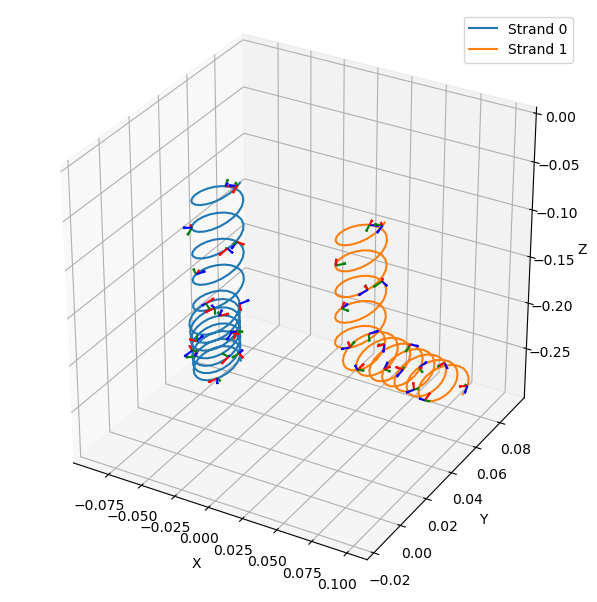

In [250]:
from rod.helix_util import HelixUtil
def add_one_twist_new(pos, theta, twist_idx=100, twist_angle_rad=np.pi/6, arc_step=0.00049065):
    '''
    Apply twist at one point
    '''
    helix = RodHelixConverter.rod_to_helix(pos=pos, theta=theta)

    twist_index = twist_idx
    arc_step = arc_step

    # Compute twist rate (tau) per unit arc length
    tau = twist_angle_rad / arc_step

    # Apply twist at twist_index
    helix.q[3 * twist_index] = tau

    r, n = HelixUtil.propagate(helix)

    return RodHelixConverter.helix_to_rod(helix=helix), n

def add_many_rotation_inextensible(pos, theta, twist_indices=None, twist_values=None, twist_rate=0.8, n_iters=50):
    '''
    Apply twist to a rod and project to maintain segment inextensibility.
    Apply twist at designated twist indices by corresponding twist value. Both twist_indices and twist_values must be arrays of the same length.

    Parameters:
    - pos: (N, 3) array of vertex positions.
    - theta: passed through unchanged.
    - twist_indices: array of indices at which to apply twist. If None, randomly chosen.
    - twist_values: array of twist angles (in radians) to apply at the corresponding twist_indices.
    - twist_rate: fraction of segments to twist, if twist_indices not provided.
    - n_iters: number of projection iterations for enforcing inextensibility.

    Returns:
    - pos_rotated: (N, 3) rotated and projected positions.
    - theta: unchanged.
    '''
    pos_rotated = pos.copy()
    num_vertices = len(pos)

    # Rest lengths of each segment
    rest_lengths = np.linalg.norm(pos[1:] - pos[:-1], axis=1)

    max_twist_points = num_vertices - 1
    total_twists = int(twist_rate * max_twist_points)

    # Generate twist indices/values if not provided
    if twist_indices is None:
        twist_indices = np.random.choice(np.arange(max_twist_points), size=total_twists, replace=False)
    if twist_values is None:
        twist_values = np.random.uniform(-0.05, 0.05, size=len(twist_indices))

    for i, twist_index in enumerate(twist_indices):
        if twist_index >= num_vertices - 1:
            continue

        twist_angle = twist_values[i]
        axis = pos[twist_index + 1] - pos[twist_index]
        axis_norm = np.linalg.norm(axis)
        if axis_norm < 1e-8:
            continue
        axis = axis / axis_norm

        # Rodrigues rotation formula
        K = np.array([
            [0, -axis[2], axis[1]],
            [axis[2], 0, -axis[0]],
            [-axis[1], axis[0], 0]
        ])
        I = np.eye(3)
        R = I + np.sin(twist_angle) * K + (1 - np.cos(twist_angle)) * (K @ K)

        origin = pos[twist_index]
        for j in range(twist_index + 1, num_vertices):
            vec = pos_rotated[j] - origin
            pos_rotated[j] = origin + R @ vec

    return pos_rotated, theta


from rod.rod_generator import RodGenerator
L = 12 # 12 inches
curl_wavelength = 1 # inch
n_points = 300

poses, thetas = [], []

twist_indices = np.linspace(5, 250, 20).astype(int)
twist_values = np.random.uniform(-np.pi/4, np.pi/4, size=len(twist_indices)) # degrees
print(twist_indices)
print(twist_values)

for i in range(2):
    n_points = 256
    height_scale = L / n_points # vertical displacement per segment
    indices_per_curl = curl_wavelength / height_scale
    ang_curl_freq_default = (2 * np.pi) / indices_per_curl
    f = ang_curl_freq_default
    r, tf = 0.5, 0.8

    pos, theta = RodGenerator.example_rod(n=n_points, curl_radius=in_to_meters(r), curl_frequency=f, height_scale=in_to_meters(height_scale))
    rest_lengths = np.linalg.norm(pos[1:] - pos[:-1], axis=1)
    print(f"rest_lengths{rest_lengths}")
    print(np.linalg.norm(pos[1:] - pos[:-1], axis=1).min())  # Check segment length

    if i == 1:
        pos, theta = add_many_rotation_inextensible(pos, theta, twist_values=[np.pi/6], twist_rate=0.8, twist_indices=[101], n_iters=50)
    else:
        new_twist_values = twist_values / rest_lengths[twist_indices]
        (pos, theta), n = add_one_twist_new(pos, theta, arc_step=0.0039125150977508015)
        # pos = project_inextensibility(pos, rest_lengths)
    print(f"new length: {np.linalg.norm(pos[1:] - pos[:-1], axis=1).min()}")  # Check segment length

    pos[:, 1] -= pos[0, 1] # normalizing y
    pos[:, 2] -= pos[0, 2] # normalizing z
    pos[:, 0] += 0.1 * i
    
    poses.append(pos)
    thetas.append(theta)

strands_to_one_objs(np.array(poses), 3)
plot_strands_with_frames(poses, thetas, frame_stride=15, frame_len=0.005, n=n)



In [ ]:
# making figures for paper
from rod.rod_generator import RodGenerator

scaling_factor = 20 # 0.5meters to inches
# sim parameters
beta = 0.1 * (1 / scaling_factor**2) # bending stiffness
k = 0.0 # inextensibility
g = 9.81e-4  # scaling g instead of mass
damping = 0.5
dt = 0.08 * (1 / np.sqrt(scaling_factor))
xpbd_steps = 10
energies = [Gravity(), Bend(), Twist(), BendTwist()]

mass_default = 1.0 * (1 / scaling_factor**3) #* (1 / scaling_factor**3)#     

# trying to multiply all length scales by 10 for stability, then converting back at the end
# rad_default = 0.5 # inches
L = 12 # 12 inches
curl_wavelength = 1 # inch

twist_prev_default = 10 # twists per curl
n_points_arr = [300] #300 #300 # dimensionless
# height_scale = L / n_points # vertical displacement per segment
# indices_per_curl = curl_wavelength / height_scale
# ang_curl_freq_default = (2 * np.pi) / indices_per_curl
# twists = np.linspace(0, indices_per_curl-1, 5)

poses, thetas = [], []
sims = []

strand_labels = []

twist_indices = np.linspace(5, 250, 40).astype(int)
twist_values = np.random.uniform(-0.05, 0.05, size=len(twist_indices)) # degrees
print(twist_indices)
print(twist_values)

for i in range(2):
    n_points = 256
    height_scale = L / n_points # vertical displacement per segment
    indices_per_curl = curl_wavelength / height_scale
    ang_curl_freq_default = (2 * np.pi) / indices_per_curl
    f = ang_curl_freq_default
    r, tf = 0.5, 0.8

    strand_labels.append({'r': r, 'angular_curl_freq': f, 'twists_per_curl': 0})
    pos, theta = RodGenerator.example_rod(n=n_points, curl_radius=in_to_meters(r), curl_frequency=f, height_scale=in_to_meters(height_scale))
    rest_lengths = np.linalg.norm(pos[1:] - pos[:-1], axis=1)
    print(np.linalg.norm(pos[1:] - pos[:-1], axis=1).min())  # Check segment length

    if i == 1:
        pos, theta = add_many_rotation_inextensible(pos, theta, twist_values=twist_values, twist_rate=0.8, twist_indices=twist_indices)
    else:
        new_twist_values = twist_values / rest_lengths[twist_indices]
        pos, theta = add_twist_cum(pos, theta, twist_indices=twist_indices, twist_values=new_twist_values)
        pos = project_inextensibility(pos, rest_lengths)
    print(f"new length: {np.linalg.norm(pos[1:] - pos[:-1], axis=1).min()}")  # Check segment length

    pos[:, 1] -= pos[0, 1] # normalizing y
    pos[:, 2] -= pos[0, 2] # normalizing z
    pos[:, 0] += 0.1 * i

    # n_sites, n_edges = pos.shape[0], theta.shape[0]
    # mass = np.ones(n_sites) * mass_default

    # rho = mass_default / (L * 0.0254)  # total mass / length in meters
    # segment_length = L / n_points * 0.0254  # in meters
    # I = rho * (in_to_meters(r) ** 2) * segment_length
    # B = np.zeros((n_edges, 2, 2))
    # B[:, 0, 0] = I
    # B[:, 1, 1] = I
    
    # frozen_pos_indices = np.array([0], dtype=int)
    # frozen_theta_indices = np.array([], dtype=int)

    # sim = Sim(pos=pos, theta=theta, B=B, beta=beta, k=k, g=g, mass=mass, energies=energies,
    #             damping=damping, dt=dt, xpbd_steps=xpbd_steps, frozen_pos_indices=frozen_pos_indices,
    #             frozen_theta_indices=frozen_theta_indices)
    # sim.define_rest_state(pos=pos, theta=theta)
    
    poses.append(pos)
    thetas.append(theta)
    # sims.append(sim)

strands_to_one_objs(np.array(poses), 3)

[  5  11  17  23  30  36  42  48  55  61  67  74  80  86  92  99 105 111
 118 124 130 136 143 149 155 162 168 174 180 187 193 199 206 212 218 224
 231 237 243 250]
[-0.04244966  0.02532462 -0.02276981  0.03974304  0.00265785  0.03007498
  0.04789314  0.03397889  0.03669938 -0.00920155  0.00517226 -0.02461114
 -0.03038869  0.00055079  0.0095049  -0.01607288  0.00694435  0.03874605
  0.00567216  0.02208131  0.0305315   0.04887288  0.01031974  0.03068501
  0.04626493  0.04444097 -0.03589182 -0.00936077 -0.01760099 -0.0413075
  0.01332408  0.02359046  0.03481281 -0.03772231  0.03764441  0.01429256
  0.02039461  0.0410624   0.01247613 -0.01641341]
0.0039125150977508015
new length: 0.0039036205780892466
0.0039125150977508015
new length: 0.003890054684623038


In [ ]:
poses, thetas = [], []
sims = []

strand_labels = []

L = 12
wavelengths = [0.0, 1.0]
# for i, wavelength in enumerate(wavelengths):
for i in range(2):
    n_points = 300
    height_scale = L / n_points  # vertical displacement per segment (in inches)

    # Compute number of segments per curl
    indices_per_curl = curl_wavelength / height_scale
    ang_curl_freq = (2 * np.pi) / indices_per_curl  # angular frequency in radians per segment

    r = 0.5  # curl radius in inches
    tf = 0.9  # twist factor (dimensionless, total twists per curl)
    tf = int(tf * indices_per_curl)

    # Save strand label metadata
    strand_labels.append({
        'r': r,
        'angular_curl_freq': ang_curl_freq,
        'twists_per_curl': 0
    })

    # Generate example rod in meters
    pos, theta = RodGenerator.example_rod(
        n=n_points,
        curl_radius=in_to_meters(r),
        curl_frequency=ang_curl_freq,
        height_scale=in_to_meters(height_scale)
    )

    # Check segment length sanity
    print("Min segment length:", np.linalg.norm(pos[1:] - pos[:-1], axis=1).min())

    # Add cumulative twist along rod
    rest_lengths = np.linalg.norm(pos[1:] - pos[:-1], axis=1)
    # pos, theta = add_twist_cum(pos, theta, tf, ang_curl_freq, indices_per_curl)
    twist_indices = np.linspace(5, 245, 50).astype(int)
    pos, theta = add_many_rotation_inextensible(pos, theta, twist_value=2*np.pi, twist_rate=0.9, twist_indices=twist_indices)
    # pos = project_inextensibility(pos, rest_lengths, max_iters=20)

    # Normalize rod position in Y and Z
    pos[:, 1:] -= pos[0, 1:]
    pos[:, 0] += 0.1 * i  # offset rods in X to prevent overlap

    # Set up mass and inertia
    n_sites, n_edges = pos.shape[0], theta.shape[0]
    mass = np.ones(n_sites) * mass_default
    rho = mass_default / (L * 0.0254)  # linear mass density (kg/m)
    segment_length_m = in_to_meters(height_scale)
    I = rho * (in_to_meters(r) ** 2) * segment_length_m  # moment of inertia

    B = np.zeros((n_edges, 2, 2))
    B[:, 0, 0] = I
    B[:, 1, 1] = I

    # Constraint setup
    frozen_pos_indices = np.array([0], dtype=int)
    frozen_theta_indices = np.array([], dtype=int)

    # Build simulation object
    sim = Sim(
        pos=pos,
        theta=theta,
        B=B,
        beta=beta,
        k=k,
        g=g,
        mass=mass,
        energies=energies,
        damping=damping,
        dt=dt,
        xpbd_steps=xpbd_steps,
        frozen_pos_indices=frozen_pos_indices,
        frozen_theta_indices=frozen_theta_indices
    )
    sim.define_rest_state(pos=pos, theta=theta)

    # Store results
    poses.append(pos)
    thetas.append(theta)
    sims.append(sim)

# Export all strands to single object
# strands_to_one_objs(np.array(poses), 3)
strands_to_one_objs(poses, 1)


Min segment length: 0.003341661246016114


TypeError: add_many_rotation_inextensible() got an unexpected keyword argument 'twist_value'

In [69]:
def plot_cls(poses):
    """
    Creates an interactive visualization of multiple centerlines.

    Parameters:
    - poses: [(n_sites, 3)] Centerline positions
    """
    # Create figure
    fig = go.Figure()

    # Plot each helix
    for idx, pos in enumerate(poses):
        # Plot centerline
        fig.add_trace(go.Scatter3d(
            x=pos[:, 0], y=pos[:, 1], z=pos[:, 2],
            mode='lines',
            line=dict(width=3),
            name=f'Centerline {idx + 1}'
        ))


    # Update layout
    fig.update_layout(
        scene=dict(
            # xaxis=dict(title='X', range=[x_min, x_max]),
            # yaxis=dict(title='Y', range=[y_min, y_max]),
            # zaxis=dict(title='Z', range=[z_min, z_max]),
            # aspectmode='cube',
            # aspectratio=dict(x=1, y=1, z=1)
            xaxis=dict(title='X'),
            yaxis=dict(title="Y"),
            zaxis=dict(title='Z'),
            aspectmode='data'
        ),
        title=dict(text='CL Visualization', y=0.95, x=0.5, xanchor='center', yanchor='top'),
    )

    fig.show()

In [70]:
poses = np.asarray(poses)
points = poses[0]
x_min, x_max = points[:, 0].min(), points[:, 0].max()
y_min, y_max = points[:, 1].min(), points[:, 1].max()
z_min, z_max = points[:, 2].min(), points[:, 2].max()
print(x_min, x_max)
print(y_min, y_max)
print(z_min, z_max)
plot_cls([poses])

0.0 0.0
0.0 0.0
-0.307848 0.0


In [71]:
from concurrent.futures import ProcessPoolExecutor

tracking_freq = 20
n_strands = 5
tracking_freq = 20

def step_wrapper(i, pos, theta, sim, n_steps=10):
    for _ in range(n_steps):
        pos, theta = sim.step(pos=pos, theta=theta)
    return i, pos, theta, sim

progress = tqdm(range(10 * tracking_freq))
with ProcessPoolExecutor() as executor:
    for i in progress:
        futures = [executor.submit(step_wrapper, j, poses[j], thetas[j], sims[j], n_steps=1) for j in range(n_strands)]
        results = [f.result() for f in futures]
        for j, pos, theta, sim in results:
            poses[j] = pos
            thetas[j] = theta

        if i % tracking_freq == 0:
            progress.set_description(f"Frame {i // tracking_freq}")
            strands_to_one_objs(np.array(poses), i // tracking_freq + 1)

data_to_save = {
    'poses': poses,  # list of numpy arrays
    'labels': strand_labels  # list of dicts
}

np.save("more_twist_samples.npy", data_to_save, allow_pickle=True)

  0%|          | 0/200 [00:00<?, ?it/s]Process SpawnProcess-11:
Process SpawnProcess-12:
Process SpawnProcess-13:
Traceback (most recent call last):
  File "/Users/carolynsmith/opt/anaconda3/lib/python3.9/multiprocessing/process.py", line 315, in _bootstrap
    self.run()
  File "/Users/carolynsmith/opt/anaconda3/lib/python3.9/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/Users/carolynsmith/opt/anaconda3/lib/python3.9/concurrent/futures/process.py", line 240, in _process_worker
    call_item = call_queue.get(block=True)
  File "/Users/carolynsmith/opt/anaconda3/lib/python3.9/multiprocessing/queues.py", line 122, in get
    return _ForkingPickler.loads(res)
Traceback (most recent call last):
AttributeError: Can't get attribute 'step_wrapper' on <module '__main__' (built-in)>
  File "/Users/carolynsmith/opt/anaconda3/lib/python3.9/multiprocessing/process.py", line 315, in _bootstrap
    self.run()
  File "/Users/carolynsmith/opt/anac

KeyboardInterrupt: 